In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,155 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

In [2]:
df=pd.read_excel("/content/태림_필터링데이터(찐).xlsx")

In [3]:
df.head()

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,A0028219,PO348384,20240521-004,May,2024,27,4.8,pc,FIRM,SEA,NaN,1.656.750
1,A0028219,A0028219,PO348384,20240521-004,June,2024,3,4.8,pc,FIRM,SEA,NaN,1.656.750
2,A0028219,A0028219,PO348384,20240521-004,June,2024,10,6.4,pc,FIRM,SEA,NaN,1.656.750
3,A0028219,A0028219,PO348384,20240521-004,June,2024,26,6.4,pc,FORECAST,SEA,NaN,1.656.750
4,A0028219,A0028219,PO348384,20240521-004,July,2024,4,6.4,pc,FORECAST,SEA,NaN,1.656.750


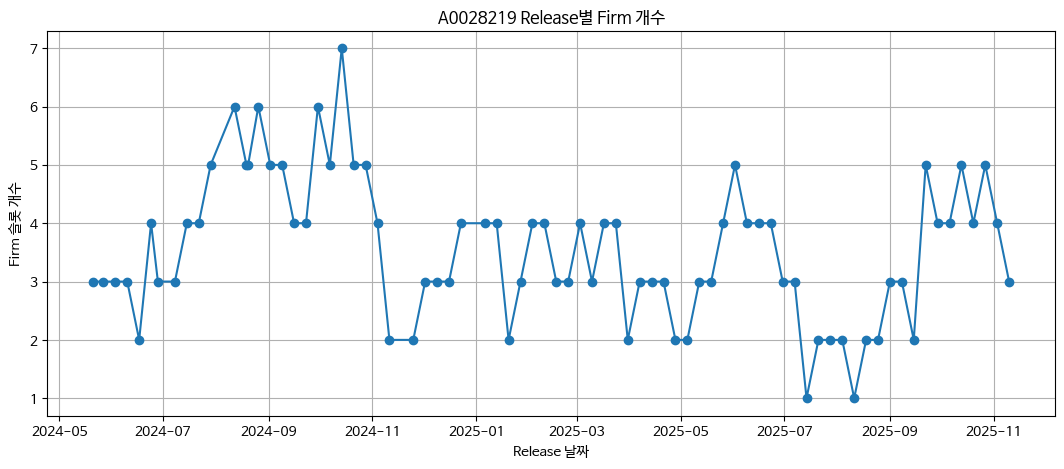

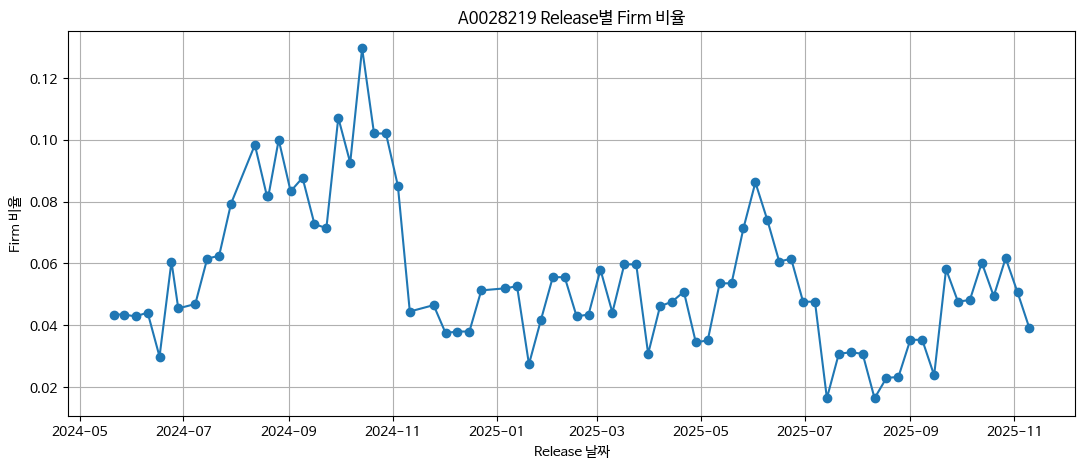

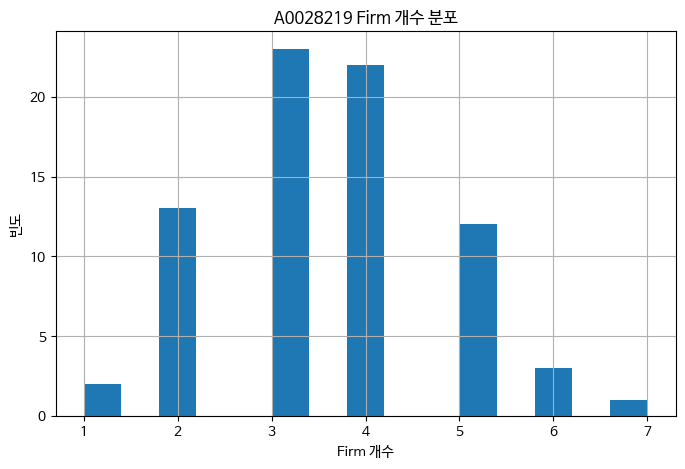

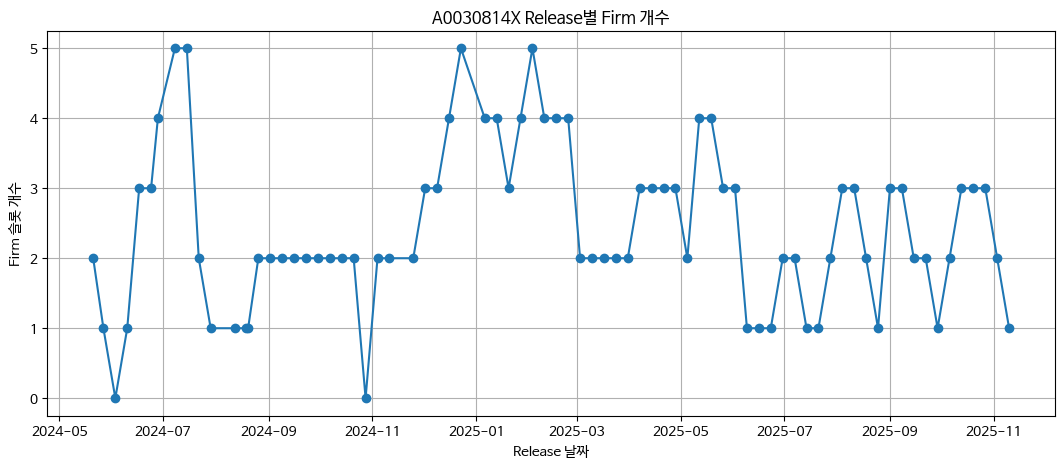

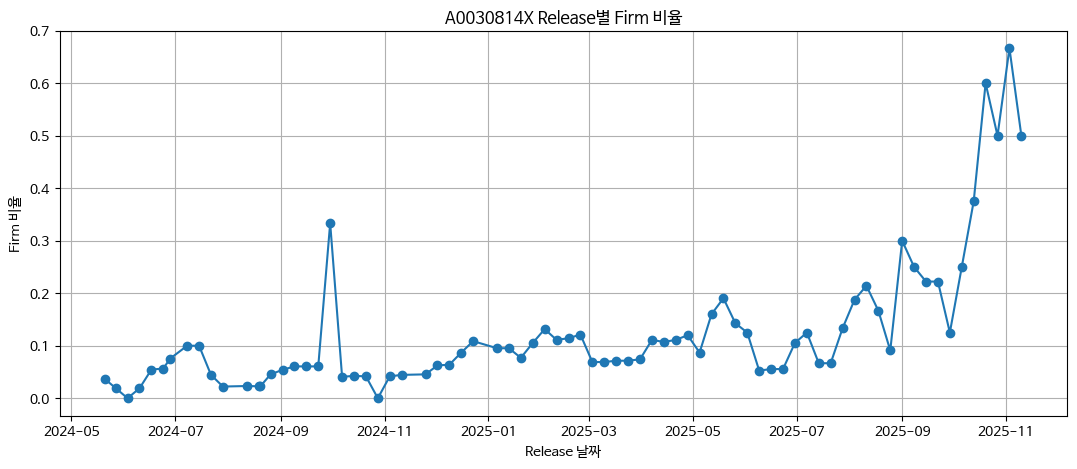

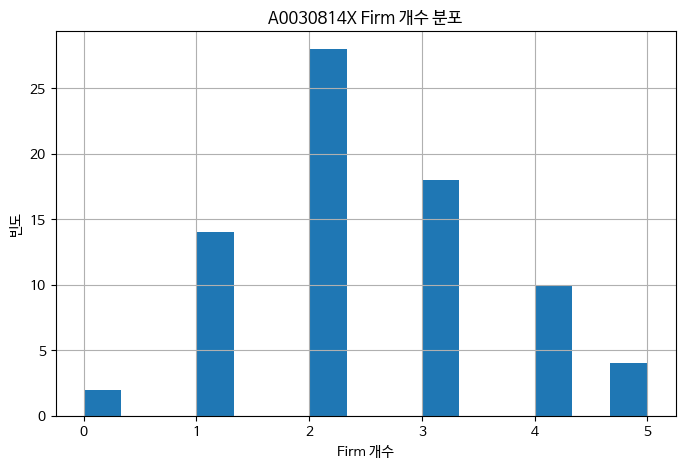

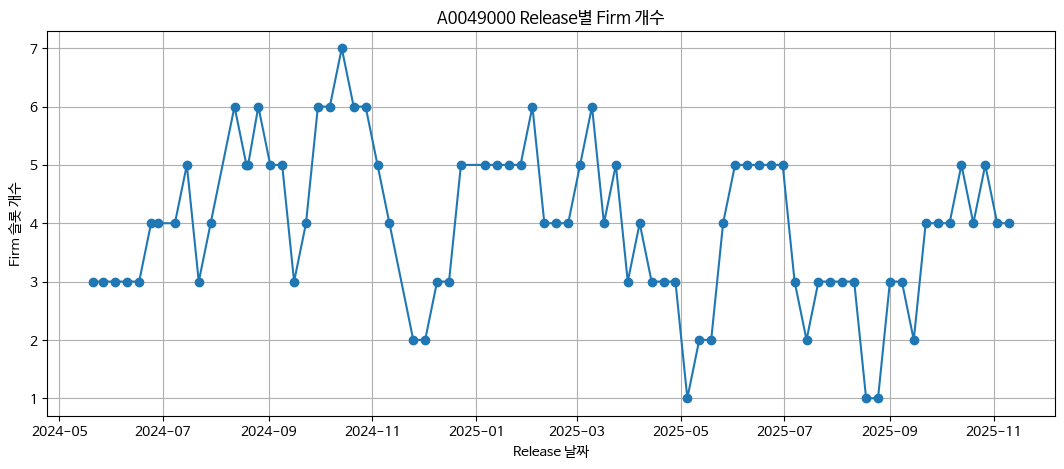

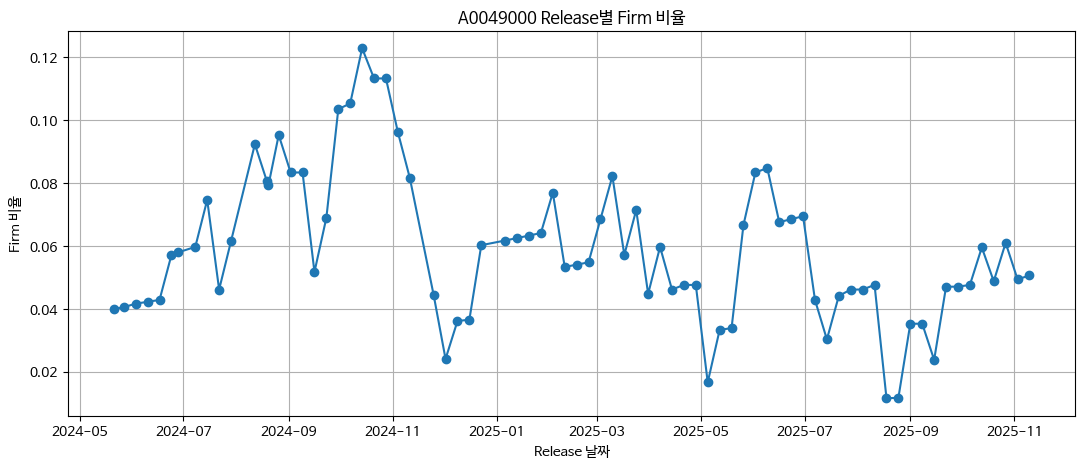

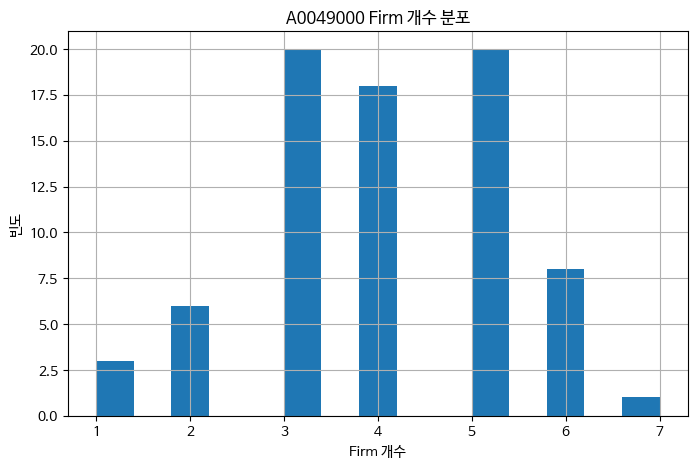

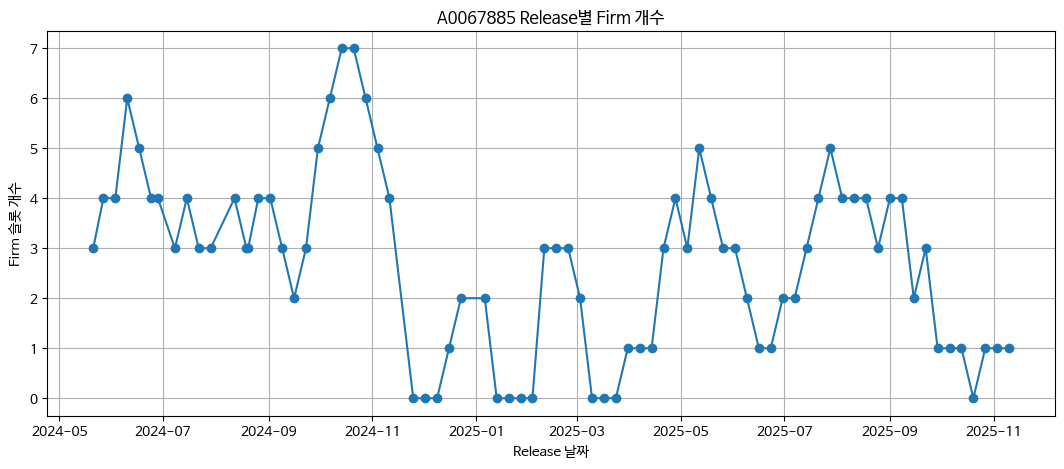

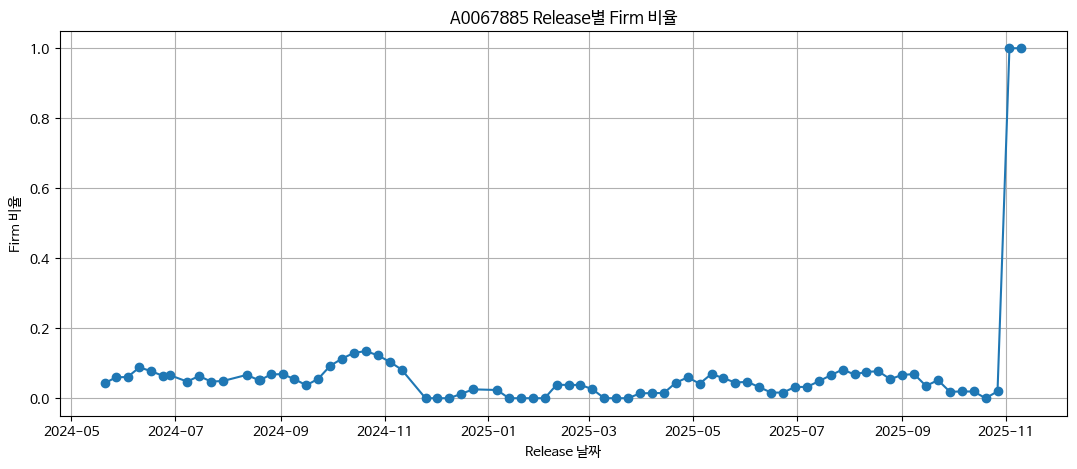

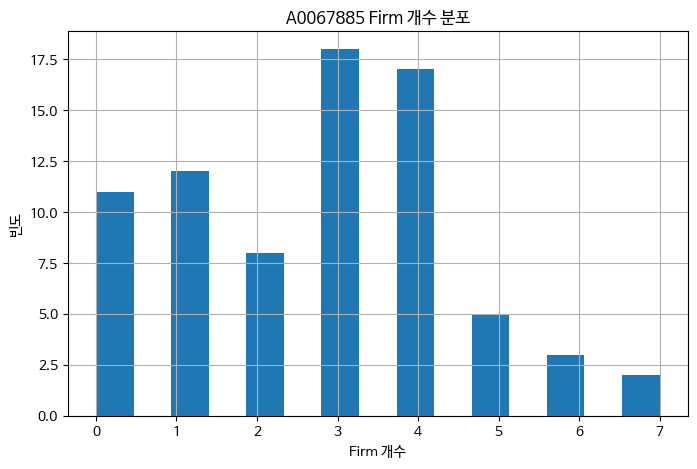

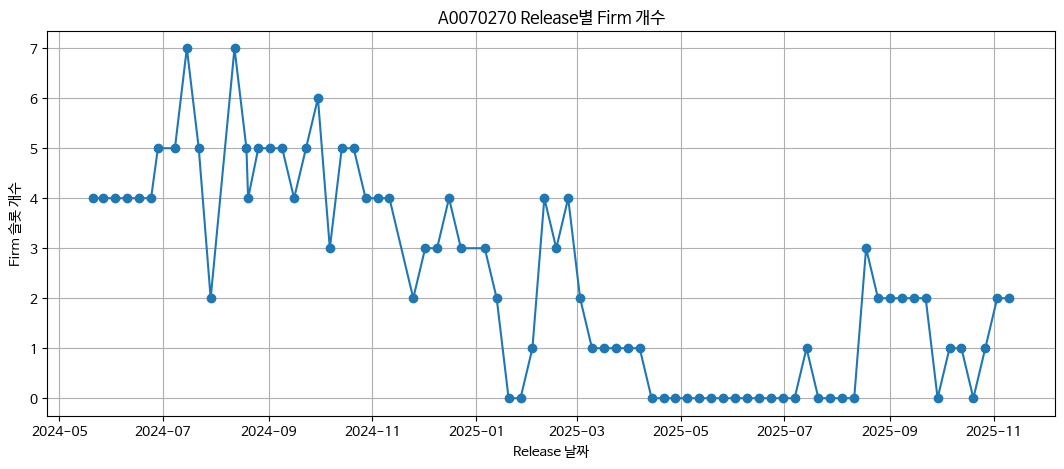

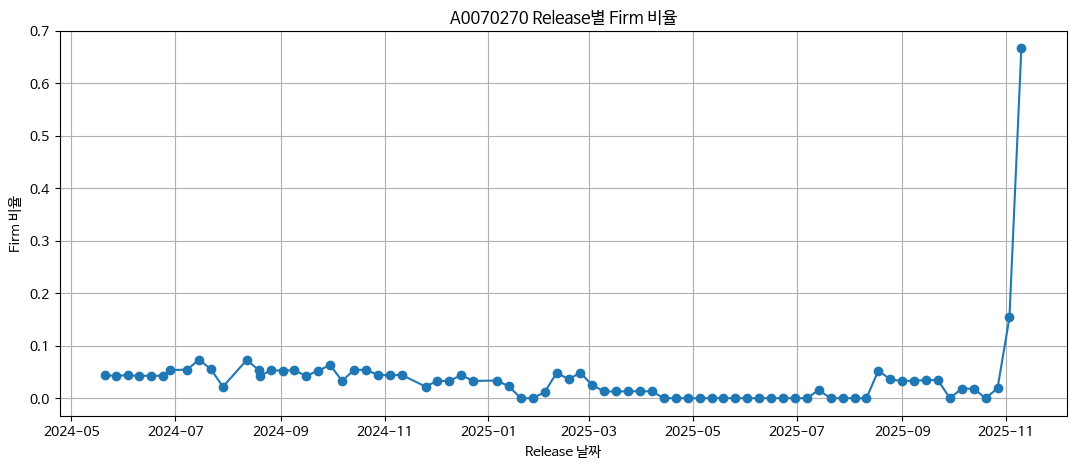

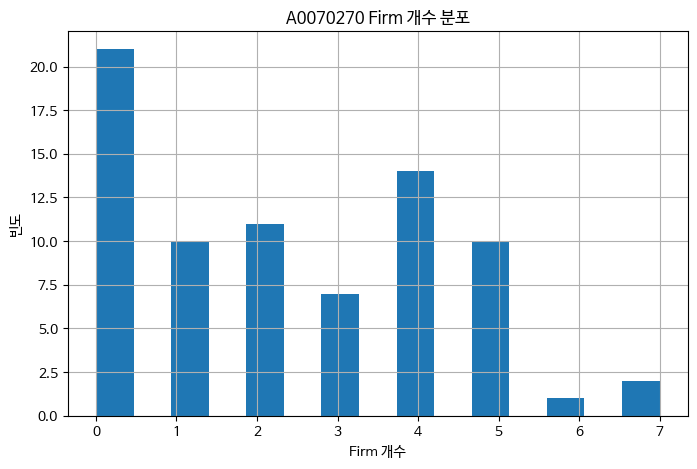

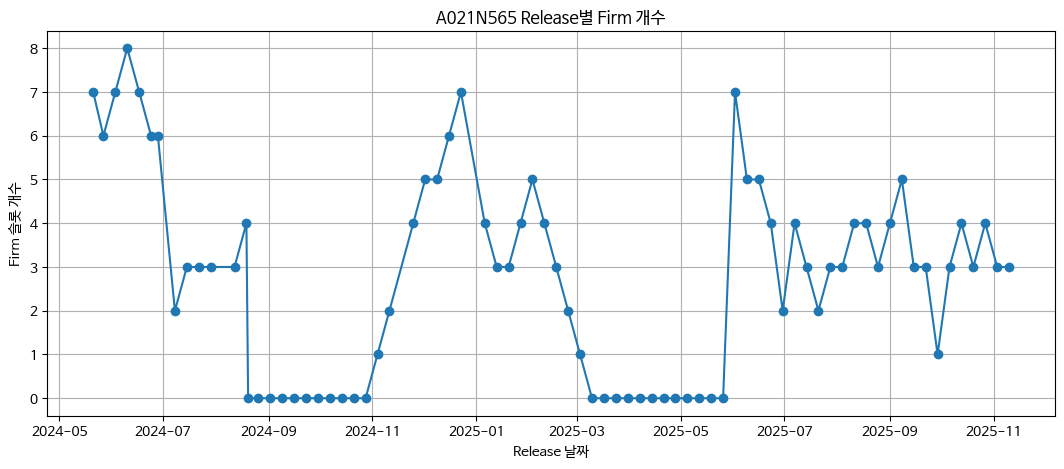

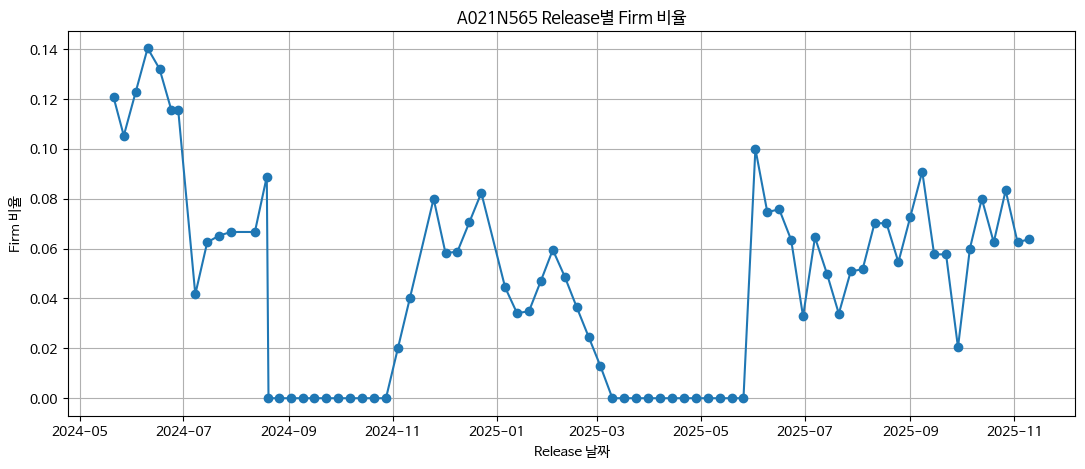

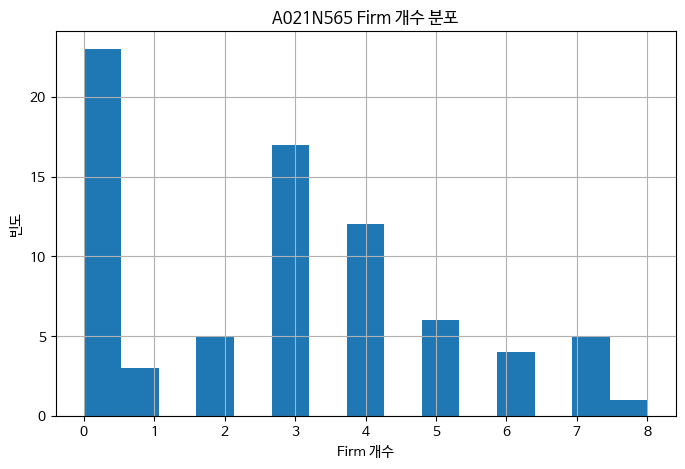

In [4]:

import matplotlib.font_manager as fm

# release 날짜 생성
df["release_date"] = pd.to_datetime(df["ID_Release"].str[:8], format="%Y%m%d")

# 출하 예정일 생성
df["ship_date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-" +
    df["Day"].astype(str)
)

# ship_slot 생성
df["ship_slot"] = df["ZF_PN"].astype(str) + "_" + df["ship_date"].astype(str)

# firm 여부
df["is_firm"] = (df["Firm/Forecast"] == "FIRM").astype(int)

products = df["ZF_PN"].unique()

for pn in products:

    temp = df[df["ZF_PN"] == pn].copy()
    temp = temp.sort_values("release_date")

    temp = temp.drop_duplicates(["release_date","ship_slot"], keep="last")

    firm_count = temp.groupby("release_date")["is_firm"].sum()
    total_count = temp.groupby("release_date")["ship_slot"].count()
    firm_ratio = firm_count / total_count

    # ================================
    # ⭐ 그래프1 Firm 개수
    # ================================
    plt.figure(figsize=(13,5))
    plt.plot(firm_count.index, firm_count.values, marker='o')
    plt.title(f"{pn} Release별 Firm 개수")
    plt.xlabel("Release 날짜")
    plt.ylabel("Firm 슬롯 개수")
    plt.grid()
    plt.show()

    # ================================
    # ⭐ 그래프2 Firm 비율
    # ================================
    plt.figure(figsize=(13,5))
    plt.plot(firm_ratio.index, firm_ratio.values, marker='o')
    plt.title(f"{pn} Release별 Firm 비율")
    plt.xlabel("Release 날짜")
    plt.ylabel("Firm 비율")
    plt.grid()
    plt.show()

    # ================================
    # ⭐ 그래프3 Firm 개수 분포
    # ================================
    plt.figure(figsize=(8,5))
    plt.hist(firm_count.values, bins=15)
    plt.title(f"{pn} Firm 개수 분포")
    plt.xlabel("Firm 개수")
    plt.ylabel("빈도")
    plt.grid()
    plt.show()


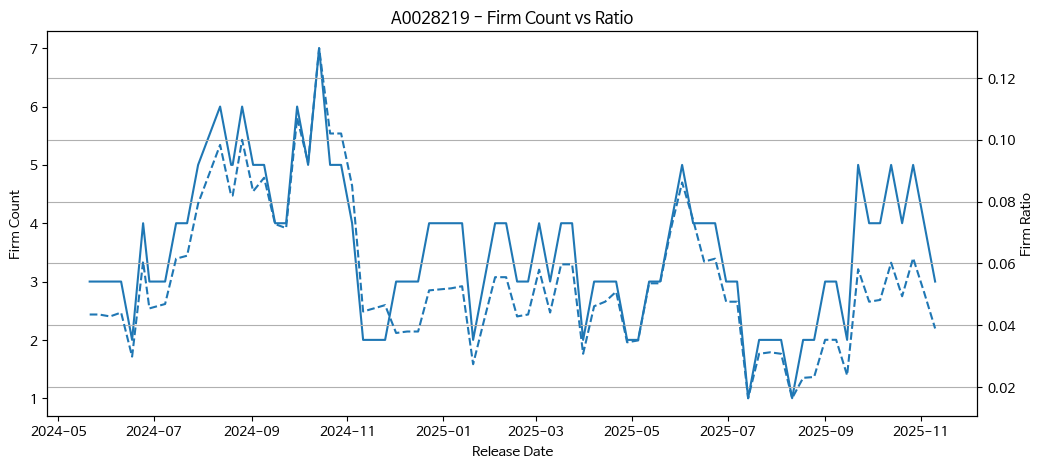

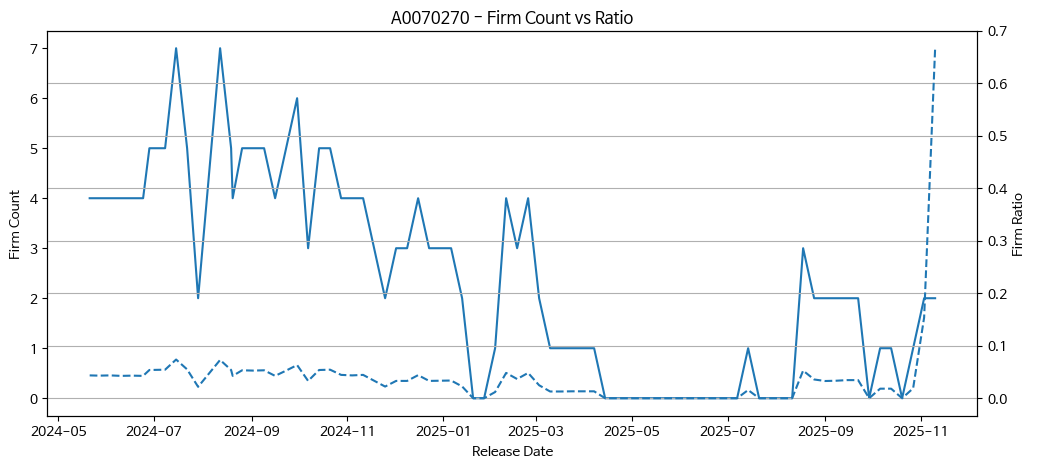

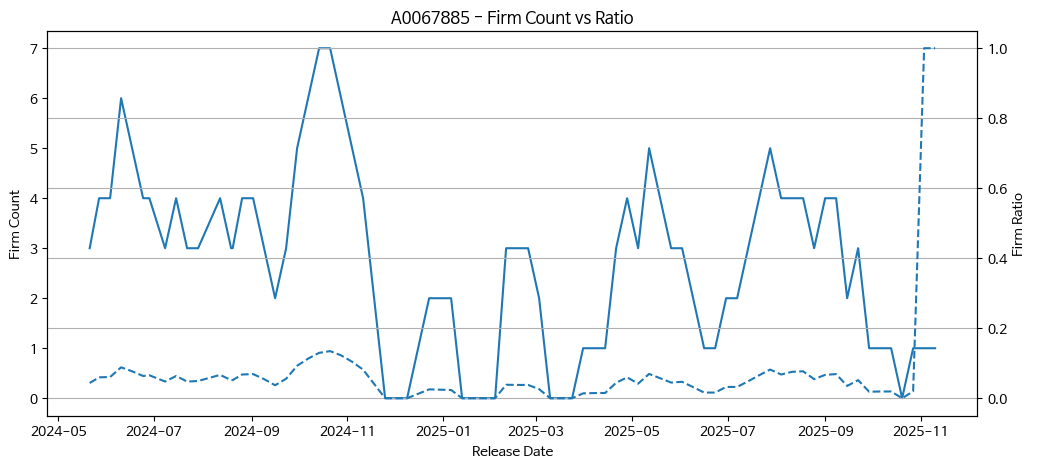

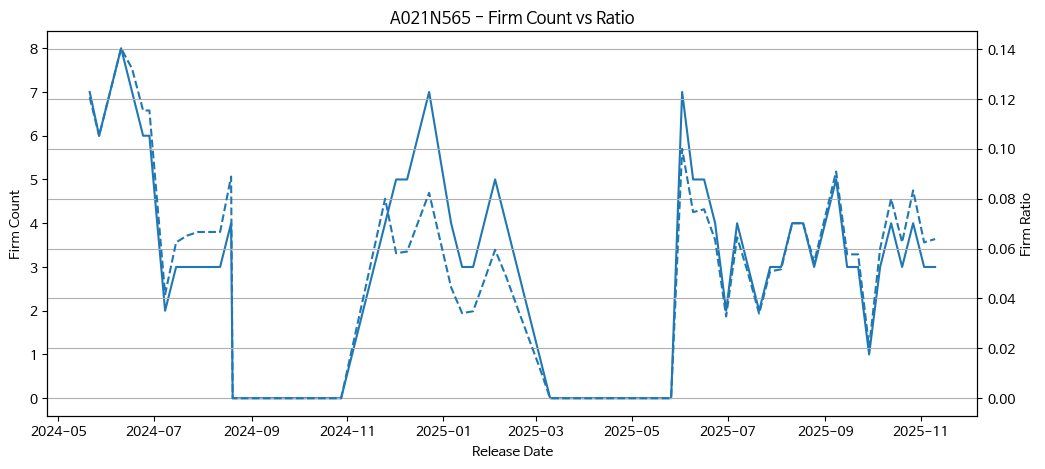

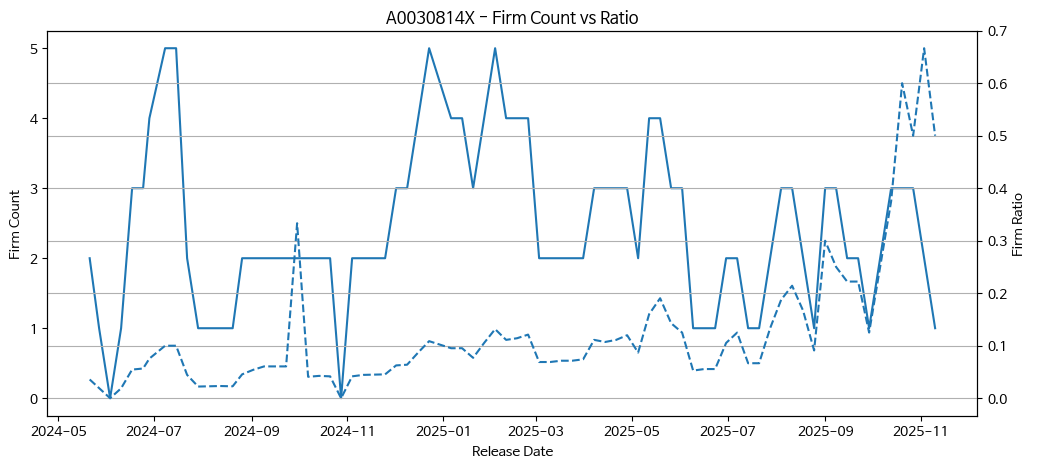

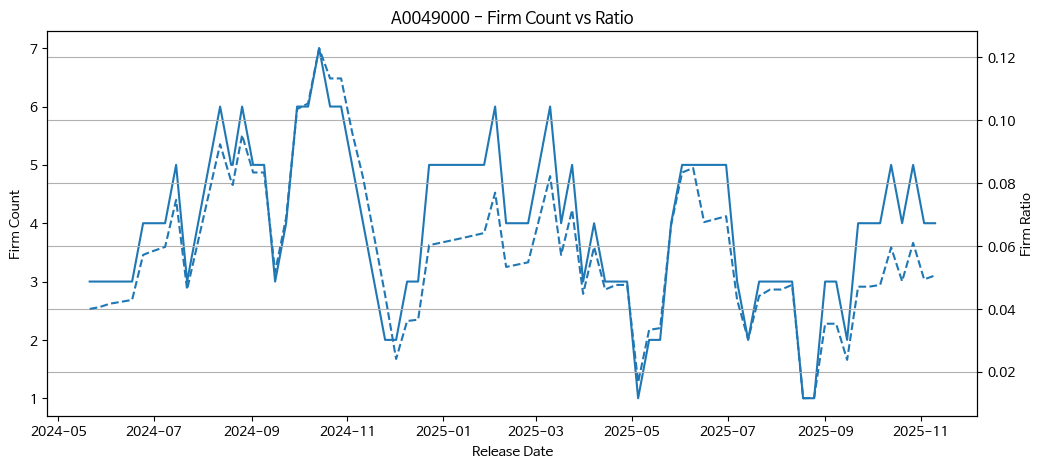

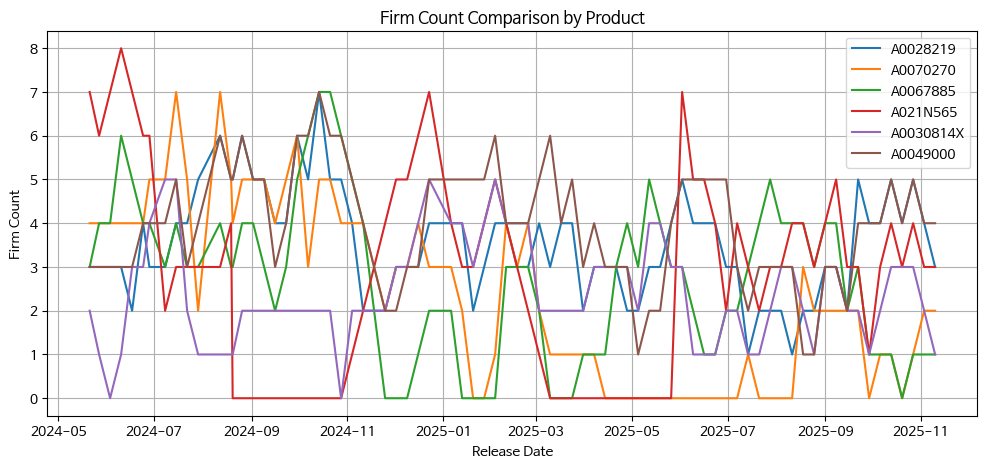

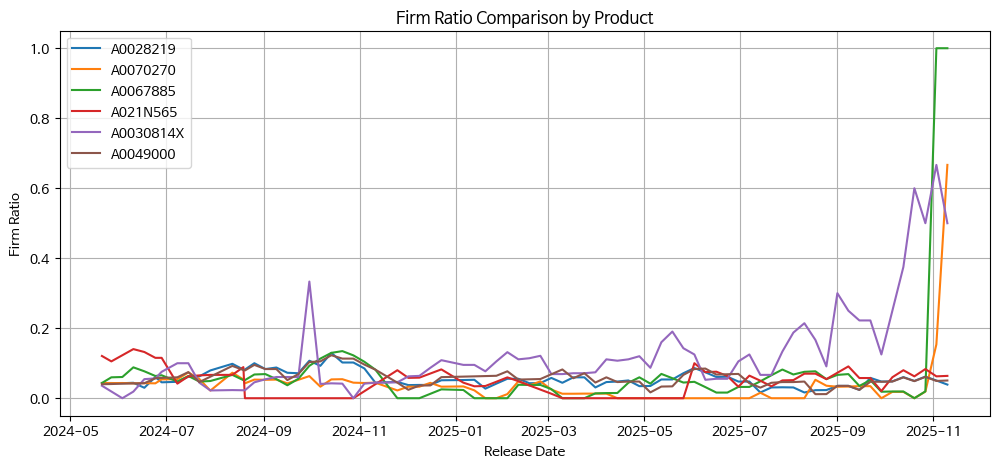

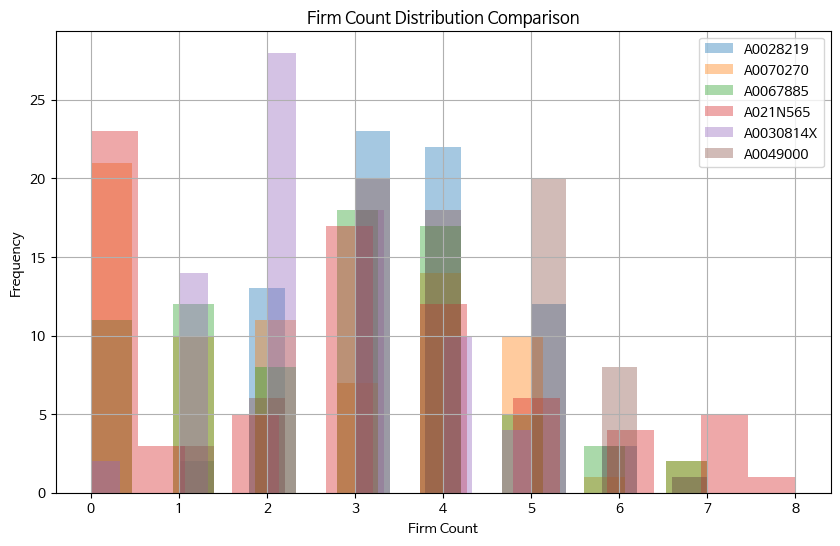

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 데이터 불러오기
# ================================
df = pd.read_excel("/content/태림_필터링데이터(찐).xlsx")

# 날짜 처리
df["release_date"] = pd.to_datetime(df["ID_Release"].str[:8], format="%Y%m%d")

df["ship_date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-" +
    df["Day"].astype(str)
)

# ship_slot 생성
df["ship_slot"] = df["ZF_PN"].astype(str) + "_" + df["ship_date"].astype(str)

# Firm 여부
df["is_firm"] = (df["Firm/Forecast"] == "FIRM").astype(int)

# snapshot 구조
df = df.sort_values("release_date")
df = df.drop_duplicates(["ZF_PN","release_date","ship_slot"], keep="last")

products = df["ZF_PN"].unique()

# ================================
# 1️⃣ 제품별 관계 그래프 (6개)
# ================================
for pn in products:

    temp = df[df["ZF_PN"] == pn]

    firm = temp.groupby("release_date")["is_firm"].sum()
    total = temp.groupby("release_date")["ship_slot"].count()
    ratio = firm / total

    fig, ax1 = plt.subplots(figsize=(12,5))

    # Firm Count (왼쪽 축)
    ax1.plot(firm.index, firm.values)
    ax1.set_ylabel("Firm Count")
    ax1.set_xlabel("Release Date")

    # Firm Ratio (오른쪽 축)
    ax2 = ax1.twinx()
    ax2.plot(ratio.index, ratio.values, linestyle='--')
    ax2.set_ylabel("Firm Ratio")

    plt.title(f"{pn} - Firm Count vs Ratio")
    plt.grid()
    plt.show()

# ================================
# 2️⃣ 제품별 비교 그래프 (총 3개)
# ================================

# (1) Firm Count 비교
plt.figure(figsize=(12,5))
for pn in products:
    temp = df[df["ZF_PN"] == pn]
    firm = temp.groupby("release_date")["is_firm"].sum()
    plt.plot(firm.index, firm.values, label=pn)

plt.title("Firm Count Comparison by Product")
plt.xlabel("Release Date")
plt.ylabel("Firm Count")
plt.legend()
plt.grid()
plt.show()

# (2) Firm Ratio 비교
plt.figure(figsize=(12,5))
for pn in products:
    temp = df[df["ZF_PN"] == pn]
    firm = temp.groupby("release_date")["is_firm"].sum()
    total = temp.groupby("release_date")["ship_slot"].count()
    ratio = firm / total
    plt.plot(ratio.index, ratio.values, label=pn)

plt.title("Firm Ratio Comparison by Product")
plt.xlabel("Release Date")
plt.ylabel("Firm Ratio")
plt.legend()
plt.grid()
plt.show()

# (3) Histogram 비교
plt.figure(figsize=(10,6))
for pn in products:
    temp = df[df["ZF_PN"] == pn]
    firm = temp.groupby("release_date")["is_firm"].sum()
    plt.hist(firm.values, bins=15, alpha=0.4, label=pn)

plt.title("Firm Count Distribution Comparison")
plt.xlabel("Firm Count")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()